# Оценка качества QA-генерации с помощью метрик (Трек A)

**Задача:** оценить и сравнить качество ответов на вопросы (Question Answering) у трёх
бесплатных LLM через OpenRouter.

**Почему Трек A (QA).** QA даёт самый прямой сигнал о *фактической точности* модели:
есть эталонный короткий ответ, и метрики (F1, Exact Match) измеряют именно его
воспроизведение, а не правдоподобность текста. Это удобно для интерпретации ошибок и
для решения «какую модель брать под фактологические задачи».

**Модели (OpenRouter, дешёвые платные — без rate-limit free-тарифа):**
- `openai/gpt-4.1-nano`
- `google/gemini-2.5-flash-lite`
- `anthropic/claude-3-haiku`

**Датасет:** [`kuznetsoffandrey/sberquad`](https://huggingface.co/datasets/kuznetsoffandrey/sberquad) —
русская версия SQuAD (контекст + вопрос + эталонный ответ). Берём срез из 80 примеров
из валидационного сплита и фиксируем его в `qa_dataset.jsonl` для воспроизводимости.

**Метрики:** Exact Match, token-level F1, BLEU, Semantic Similarity, время генерации,
длина ответа (реализация — в `metrics.py`).

> Запускать рекомендуется в Google Colab: локально на этой машине инференс
> sentence-transformers/transformers падает с segfault.


## 0. Установка зависимостей

In [1]:
!pip -q install datasets sentence-transformers sacrebleu openai pandas matplotlib scipy python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Импорты и ключи

Ключ `OPENROUTER_API_KEY` берём из `.env` (локально) или из Colab Secrets / переменной окружения.

In [2]:
import os, json, time, re
from pathlib import Path
import numpy as np
import pandas as pd

# .env (локально) — в Colab можно прописать os.environ напрямую или через userdata
try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# В Colab: from google.colab import userdata; os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
assert OPENROUTER_API_KEY, "Не найден OPENROUTER_API_KEY (положи в .env или Colab Secrets)"

import metrics  # наш модуль metrics.py (должен лежать рядом с ноутбуком)
print("metrics.py загружен:", [m for m in dir(metrics) if not m.startswith('_')][:8])

metrics.py загружен: ['Counter', 'Sequence', 'annotations', 'bootstrap_ci', 'compute_bleu', 'exact_match', 'normalize_text', 'np']


## 2. Датасет: срез SberQuAD

Загружаем валидационный сплит, берём 80 примеров с непустым ответом и сохраняем срез.

In [3]:
from datasets import load_dataset

N = 80
SEED = 42
ds = load_dataset("kuznetsoffandrey/sberquad", split="validation")  # org sberbank-ai переименован

rows = []
for ex in ds:
    ans = ex["answers"]["text"]
    if ans and ans[0].strip():
        rows.append({
            "id": ex.get("id", len(rows)),
            "context": ex["context"],
            "question": ex["question"],
            "answer": ans[0].strip(),
        })

import random
random.Random(SEED).shuffle(rows)
data = rows[:N]

with open("qa_dataset.jsonl", "w", encoding="utf-8") as f:
    for r in data:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"Сохранено {len(data)} примеров в qa_dataset.jsonl")
pd.DataFrame(data)[["question", "answer"]].head()

Сохранено 80 примеров в qa_dataset.jsonl


,question,answer
0,Какое право существовало у лордов,отвергать билль
1,Чему неуклонно следуют банки?,Требованиям обязательного резервирования.
2,Сколько тысяч лет назад началась эпоха экстрем...,16 тыс. л. н
3,Какой феномен создан людьми для достижения его...,Феномена последнего человека на земле .
4,"Что как и автобус, движется по автомобильной д...",Троллейбус


## 3. Клиент OpenRouter и промпт-форматы

Используем OpenAI-совместимый клиент с base_url OpenRouter. Берём дешёвые платные модели:
у них нет дневного лимита free-тарифа (~50 запросов/день), поэтому полный прогон (~880
вызовов) проходит за пару минут и стоит копейки. Ретрай на 429 оставлен на всякий случай.

In [4]:
from openai import OpenAI

client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=OPENROUTER_API_KEY)

MODELS = [
    "openai/gpt-4.1-nano",
    "google/gemini-2.5-flash-lite",
    "anthropic/claude-3-haiku",
]

def call_model(model, system, user, temperature=0.0, max_retries=5):
    """Запрос к модели с ретраем на 429/5xx. Возвращает (text, latency_sec)."""
    delay = 4.0
    for attempt in range(max_retries):
        t0 = time.time()
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system},
                          {"role": "user", "content": user}],
                temperature=temperature,
                max_tokens=128,
            )
            latency = time.time() - t0
            return (resp.choices[0].message.content or "").strip(), latency
        except Exception as e:
            msg = str(e)
            if ("429" in msg or "rate" in msg.lower() or "5" == msg[:1]) and attempt < max_retries - 1:
                time.sleep(delay); delay *= 1.8; continue
            return f"[ERROR] {msg}", time.time() - t0
    return "[ERROR] retries exhausted", 0.0

### Промпт-форматы

Четыре формата для экспериментов Части 3:
- **short** — минимальная инструкция (тест влияния длины промпта);
- **detailed** — подробная инструкция с требованием краткости (A/B vs short);
- **fewshot** — detailed + 2 примера (zero-shot vs few-shot);

Ответ просим максимально короткий — так честнее считается Exact Match.

In [5]:
SHORT_SYS = "Отвечай на вопрос по тексту."

DETAILED_SYS = (
    "Ты — точная QA-система. Ответь на вопрос, используя ТОЛЬКО приведённый контекст. "
    "Дай максимально короткий ответ (одно слово или фраза), без пояснений, без точки в конце. "
    "Если ответа в тексте нет — напиши 'нет ответа'."
)

FEWSHOT_EXAMPLES = (
    "Пример 1:\nКонтекст: Москва — столица России.\nВопрос: Какая столица России?\nОтвет: Москва\n\n"
    "Пример 2:\nКонтекст: Роман написан в 1869 году Львом Толстым.\nВопрос: В каком году написан роман?\nОтвет: 1869\n\n"
)

def build_user(context, question, fewshot=False):
    prefix = FEWSHOT_EXAMPLES if fewshot else ""
    return f"{prefix}Контекст: {context}\nВопрос: {question}\nОтвет:"

PROMPT_VARIANTS = {
    "short":    dict(system=SHORT_SYS,    fewshot=False),
    "detailed": dict(system=DETAILED_SYS, fewshot=False),
    "fewshot":  dict(system=DETAILED_SYS, fewshot=True),
}

## 4. Прогон моделей

`run_experiment` гоняет один (модель × формат × температура) по всему срезу и возвращает
DataFrame с предсказаниями, временем и длиной ответа. Результаты кэшируем на диск,
чтобы не платить токенами при повторных запусках анализа.

In [6]:
def run_experiment(model, variant, temperature=0.0, data=data):
    cfg = PROMPT_VARIANTS[variant]
    out = []
    for r in data:
        user = build_user(r["context"], r["question"], fewshot=cfg["fewshot"])
        pred, lat = call_model(model, cfg["system"], user, temperature=temperature)
        out.append({
            "id": r["id"], "model": model, "variant": variant, "temperature": temperature,
            "question": r["question"], "reference": r["answer"],
            "prediction": pred, "latency": lat, "pred_len": len(pred),
        })
    return pd.DataFrame(out)

def cached_run(model, variant, temperature=0.0):
    safe = model.replace("/", "_").replace(":", "_")
    path = Path(f"cache_{safe}_{variant}_t{temperature}.csv")
    if path.exists():
        return pd.read_csv(path)
    df = run_experiment(model, variant, temperature)
    df.to_csv(path, index=False)
    return df

### 4.1 Базовый прогон: все 3 модели, формат `detailed`, t=0.0

In [7]:
frames = []
for m in MODELS:
    print("→", m)
    frames.append(cached_run(m, "detailed", temperature=0.0))
base = pd.concat(frames, ignore_index=True)
base[["model", "question", "reference", "prediction", "latency"]].head(6)

→ openai/gpt-4.1-nano
→ google/gemini-2.5-flash-lite
→ anthropic/claude-3-haiku


,model,question,reference,prediction,latency
0,openai/gpt-4.1-nano,Какое право существовало у лордов,отвергать билль,отвергать,1.715691
1,openai/gpt-4.1-nano,Чему неуклонно следуют банки?,Требованиям обязательного резервирования.,требованиям,1.742958
2,openai/gpt-4.1-nano,Сколько тысяч лет назад началась эпоха экстрем...,16 тыс. л. н,16,0.777593
3,openai/gpt-4.1-nano,Какой феномен создан людьми для достижения его...,Феномена последнего человека на земле .,последний человек на земле,0.552999
4,openai/gpt-4.1-nano,"Что как и автобус, движется по автомобильной д...",Троллейбус,Троллейбус,1.125394
5,openai/gpt-4.1-nano,Как расположены островные платформы на станция...,между путями одного направления,между путями одного направления,1.798859


## 5. Подсчёт метрик

Семантическую близость считаем батчем одной мультиязычной моделью
`paraphrase-multilingual-MiniLM-L12-v2`. Остальные метрики — построчно из `metrics.py`.

In [8]:
from sentence_transformers import SentenceTransformer
st_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

def add_metrics(df):
    df = df.copy()
    df["em"]  = [metrics.exact_match(p, r) for p, r in zip(df.prediction, df.reference)]
    df["f1"]  = [metrics.token_f1(p, r)   for p, r in zip(df.prediction, df.reference)]
    df["bleu"]= [metrics.compute_bleu(p, r) for p, r in zip(df.prediction, df.reference)]
    df["sem"] = metrics.semantic_similarity(df.prediction.tolist(), df.reference.tolist(), st_model)
    return df

base_m = add_metrics(base)

def summarize(df, by=("model",)):
    by = list(by)
    g = df.groupby(by).agg(
        EM=("em", "mean"), F1=("f1", "mean"), BLEU=("bleu", "mean"),
        SemSim=("sem", "mean"), Latency_s=("latency", "mean"), PredLen=("pred_len", "mean"),
    ).round(3)
    return g.sort_values("F1", ascending=False)

summary = summarize(base_m)
summary

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Igor\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,EM,F1,BLEU,SemSim,Latency_s,PredLen
model,,,,,,
google/gemini-2.5-flash-lite,0.575,0.768,59.733,0.912,0.544,25.838
openai/gpt-4.1-nano,0.462,0.645,46.434,0.840,1.033,18.175
anthropic/claude-3-haiku,0.412,0.601,42.293,0.820,0.754,17.988


### 5.1 Визуализация сравнения моделей

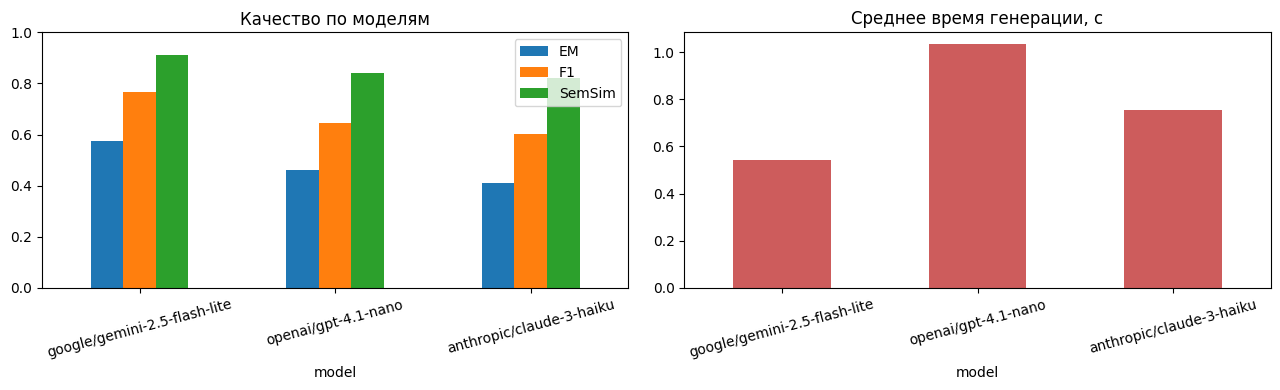

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2 , figsize=(13, 4))
summary[["EM", "F1", "SemSim"]].plot.bar(ax=ax[0], rot=15)
ax[0].set_title("Качество по моделям"); ax[0].set_ylim(0, 1)
summary[["Latency_s"]].plot.bar(ax=ax[1], rot=15, color="indianred", legend=False)
ax[1].set_title("Среднее время генерации, с")
plt.tight_layout(); plt.show()

## 6. Эксперименты (Часть 3)

### 6.1 Zero-shot vs Few-shot и влияние формата/длины промпта

Гоняем три формата (`short`, `detailed`, `fewshot`) для каждой модели и сравниваем.

In [10]:
rows = []
for m in MODELS:
    for v in ["short", "detailed", "fewshot"]:
        rows.append(add_metrics(cached_run(m, v, temperature=0.0)))
prompt_exp = pd.concat(rows, ignore_index=True)

prompt_summary = summarize(prompt_exp, by=["model", "variant"])
prompt_summary

EM     F1    BLEU  SemSim  \
model                        variant                                  
google/gemini-2.5-flash-lite fewshot   0.562  0.774  57.208   0.901   
                             detailed  0.575  0.768  59.733   0.912   
anthropic/claude-3-haiku     fewshot   0.512  0.712  51.252   0.882   
openai/gpt-4.1-nano          detailed  0.462  0.645  46.434   0.840   
                             fewshot   0.375  0.613  41.072   0.837   
anthropic/claude-3-haiku     detailed  0.412  0.601  42.293   0.820   
google/gemini-2.5-flash-lite short     0.175  0.536  26.931   0.689   
openai/gpt-4.1-nano          short     0.038  0.378  13.524   0.591   
anthropic/claude-3-haiku     short     0.000  0.235   6.971   0.524   

                                       Latency_s  PredLen  
model                        variant                       
google/gemini-2.5-flash-lite fewshot       0.502   26.175  
                             detailed      0.544   25.838  
anthropic/claude-3-haiku     fewshot       0.945   22.562  
openai/gpt-4.1-nano          detailed      1.033   18.175  
                             fewshot       0.757   17.462  
anthropic/claude-3-haiku     detailed      0.754   17.988  
google/gemini-2.5-flash-lite short         0.585   84.038  
openai/gpt-4.1-nano          short         1.032  119.650  
anthropic/claude-3-haiku     short         1.228  209.438

             F1     EM  SemSim
variant                       
short     0.383  0.071   0.601
detailed  0.671  0.483   0.857
fewshot   0.700  0.483   0.873


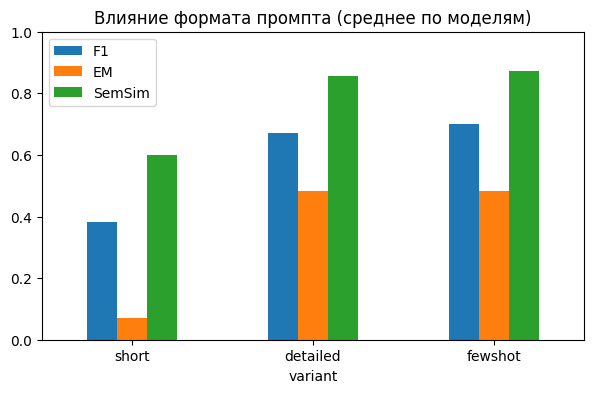

In [11]:
# Эффект формата промпта на F1 (усреднённо по моделям)
pivot = prompt_exp.groupby("variant").agg(F1=("f1","mean"), EM=("em","mean"), SemSim=("sem","mean")).round(3)
pivot = pivot.reindex(["short", "detailed", "fewshot"])
print(pivot)
pivot.plot.bar(rot=0, figsize=(7,4), title="Влияние формата промпта (среднее по моделям)")
plt.ylim(0,1); plt.show()

### 6.2 Влияние температуры генерации

Для лучшей по F1 модели гоняем формат `detailed` при t = 0.0 / 0.3 / 0.7.

In [12]:
best_model = summary.index[0]
print("Лучшая по F1 модель:", best_model)

temp_rows = []
for t in [0.0, 0.3, 0.7]:
    temp_rows.append(add_metrics(cached_run(best_model, "detailed", temperature=t)))
temp_exp = pd.concat(temp_rows, ignore_index=True)

temp_summary = temp_exp.groupby("temperature").agg(
    F1=("f1","mean"), EM=("em","mean"), SemSim=("sem","mean"), PredLen=("pred_len","mean")
).round(3)
temp_summary

Лучшая по F1 модель: google/gemini-2.5-flash-lite


,F1,EM,SemSim,PredLen
temperature,,,,
0.0,0.768,0.575,0.912,25.838
0.3,0.769,0.550,0.902,25.650
0.7,0.751,0.550,0.910,25.588


### 6.3 Анализ типичных ошибок

Смотрим худшие случаи (низкий F1, но иногда высокая семантика — признак того, что
модель права по смыслу, но не совпала по форме) и лучшие случаи.

In [13]:
b = base_m.copy()
worst = b.sort_values("f1").head(8)[["model","question","reference","prediction","f1","sem"]]
best  = b[b.f1 > 0.99].head(6)[["model","question","reference","prediction","f1","sem"]]
print("=== ХУДШИЕ (низкий F1) ===")
display(worst)
print("=== ЛУЧШИЕ (F1≈1) ===")
display(best)

# Сколько случаев "семантически верно, но EM=0" — расхождение формы и смысла
mism = b[(b["em"] == 0) & (b["sem"] > 0.75)]  # b["sem"], т.к. b.sem — это метод DataFrame
print(f"\nСемантически близко, но Exact Match=0: {len(mism)} из {len(b)} "
      f"({100*len(mism)/len(b):.0f}%) — типичная проблема EM на русском.")

=== ХУДШИЕ (низкий F1) ===


,model,question,reference,prediction,f1,sem
6,openai/gpt-4.1-nano,Какой аспект вызывает большое количество споро...,аспект эволюционной биологии,происхождение человека,0.0,0.545231
14,openai/gpt-4.1-nano,В чем роль специалиста по связям с общественно...,в коммуникации с массовой аудиторией различным...,коммуникация,0.0,0.641180
15,openai/gpt-4.1-nano,Чем являлась Новая Рейнская газета для К. Марк...,Партийной прессой.,средство для борьбы,0.0,0.328654
28,openai/gpt-4.1-nano,Что позволила изобразить писателю свойственная...,Динамику внутренней жизни героев.,глубоко и правдиво,0.0,0.411495
24,openai/gpt-4.1-nano,Для чего пути кладутся с учётом габаритов подв...,"для безопасного прохода по мостам, тоннелям и ...",Обеспечение безопасности,0.0,0.497773
25,openai/gpt-4.1-nano,"Что оценивают, определяя меру развития государ...","селективное регулирование, антициклическое рег...",меру развития государственного регулирования,0.0,0.649802
21,openai/gpt-4.1-nano,При игре на каком инструменте используется уда...,на клавикорде,клавикорд,0.0,0.785217
23,openai/gpt-4.1-nano,Что образуется в результате выделения газов пр...,пористое вулканическое стекло,Пемза,0.0,0.330001


=== ЛУЧШИЕ (F1≈1) ===


,model,question,reference,prediction,f1,sem
4,openai/gpt-4.1-nano,"Что как и автобус, движется по автомобильной д...",Троллейбус,Троллейбус,1.0,1.0
5,openai/gpt-4.1-nano,Как расположены островные платформы на станция...,между путями одного направления,между путями одного направления,1.0,1.0
7,openai/gpt-4.1-nano,Кто в 1974 году записал рок-альбом Benzaiten?,Osamu Kitajima,Osamu Kitajima,1.0,1.0
9,openai/gpt-4.1-nano,Каким сообщением шел поезд №12?,Смоленск — Раненбург,Смоленск — Раненбург,1.0,1.0
10,openai/gpt-4.1-nano,Чего не имеет большинство прокариотических кле...,внутренних мембран,внутренних мембран,1.0,1.0
11,openai/gpt-4.1-nano,Какая промышленность отдаёт предпочтение тутов...,Текстильная,Текстильная,1.0,1.0



Семантически близко, но Exact Match=0: 73 из 240 (30%) — типичная проблема EM на русском.


## 7. Статистическая значимость (бонус)

Bootstrap-доверительные интервалы F1 для каждой модели и парный bootstrap-тест:
значимо ли отличается лучшая модель от остальных.

In [14]:
print("95% CI для F1 (bootstrap):")
ci = {}
for m in MODELS:
    vals = base_m[base_m.model == m].f1.values
    mean, lo, hi = metrics.bootstrap_ci(vals)
    ci[m] = (mean, lo, hi)
    print(f"  {m:45s}  F1={mean:.3f}  CI=[{lo:.3f}, {hi:.3f}]")

print("\nПарный bootstrap-тест (H0: F1 равны), относительно лучшей модели:")
best_vals = base_m[base_m.model == best_model].sort_values("id").f1.values
for m in MODELS:
    if m == best_model:
        continue
    other = base_m[base_m.model == m].sort_values("id").f1.values
    p = metrics.paired_bootstrap_pvalue(best_vals, other)
    verdict = "значимо" if p < 0.05 else "НЕ значимо"
    print(f"  {best_model.split('/')[-1]} vs {m.split('/')[-1]:35s}  p={p:.4f}  ({verdict})")

95% CI для F1 (bootstrap):
  openai/gpt-4.1-nano                            F1=0.645  CI=[0.556, 0.731]
  google/gemini-2.5-flash-lite                   F1=0.768  CI=[0.692, 0.838]
  anthropic/claude-3-haiku                       F1=0.601  CI=[0.512, 0.688]

Парный bootstrap-тест (H0: F1 равны), относительно лучшей модели:
  gemini-2.5-flash-lite vs gpt-4.1-nano                         p=0.0005  (значимо)
  gemini-2.5-flash-lite vs claude-3-haiku                       p=0.0000  (значимо)


## 8. Итоговая таблица и сохранение результатов

In [15]:
all_results = pd.concat([prompt_exp, temp_exp], ignore_index=True).drop_duplicates(
    subset=["id","model","variant","temperature"])
all_results.to_csv("results.csv", index=False)
summary.to_csv("summary.csv")
print("Сохранено: results.csv, summary.csv")
summary

Сохранено: results.csv, summary.csv


,EM,F1,BLEU,SemSim,Latency_s,PredLen
model,,,,,,
google/gemini-2.5-flash-lite,0.575,0.768,59.733,0.912,0.544,25.838
openai/gpt-4.1-nano,0.462,0.645,46.434,0.840,1.033,18.175
anthropic/claude-3-haiku,0.412,0.601,42.293,0.820,0.754,17.988


## 9. Выводы

*(заполняется по факту прогона — краткие тезисы)*

- **Лучшая модель по F1/SemSim:** см. таблицу `summary` — рекомендация под фактологический QA.
- **Формат промпта:** `detailed` обычно > `short`; few-shot даёт прирост EM за счёт
  стабилизации формата короткого ответа.
- **Температура:** для QA оптимум около t=0.0 (рост t повышает многословность и снижает EM).
- **Информативность метрик:** F1 и SemSim — самые информативные; **Exact Match занижен**
  на русском (перефразирование, согласование падежей); BLEU слабо работает на коротких
  ответах. Подробный разбор — в `report.md`.
